# Evaluation in Relative Space

This notebook runs fresh inference on unseen ECE sensor datasets using the saved full model package

The model output is in the learned training space, the unseen device target is a relative moisture percentage signal. 

Because of that, evaluation is done in relative space so the comparison is aligned.

This is a trend tracking check, not a conversion back to physical VWC.


## Setup and Imports

In [2]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
import numpy as np

warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)


In [3]:
DEV3_PATH = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/unseen_data/sensors/d3/final_d3.csv'
DEV4_PATH = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/unseen_data/sensors/d4/final_d4.csv'
DEV7_PATH = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/unseen_data/sensors/d7/final_d7.csv'

BEST_MODEL_PATH = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/best_model.pkl'
PREDS = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/test_predictions_weighted.csv'
TRAINVAL_W = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/trainval_weights.pkl'
FULL_MODEL = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/xgb_drift_weighted_full.pkl'

PREDS_TEST = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/test_predictions_weighted.csv'

obj = joblib.load(FULL_MODEL)

model = obj["model"]
features = obj["features"]

print(f'Model loaded from FULL_MODEL: {FULL_MODEL}')
print(f'Feature count: {len(features)}')


Model loaded from FULL_MODEL: /Users/jbalkovec/Desktop/MDR/Models/Temporal/BEST_MODEL/xgb_drift_weighted_full.pkl
Feature count: 38


## Load Unseen Device Datasets

Read each device file, parse date columns if present, and inspect basic structure.


In [4]:
device_paths = {
    'd3': DEV3_PATH,
    'd4': DEV4_PATH,
    'd7': DEV7_PATH,
}

def parse_date_columns(df: pd.DataFrame) -> list:
    parsed_cols = []
    date_candidates = [
        c for c in df.columns
        if c.lower() in {'date', 'datetime', 'timestamp', 'time'} or 'date' in c.lower() or 'time' in c.lower()
    ]
    for col in date_candidates:
        parsed = pd.to_datetime(df[col], errors='coerce')
        if parsed.notna().mean() >= 0.8:
            df[col] = parsed
            parsed_cols.append(col)
    return parsed_cols

device_dfs = {}
load_rows = []

for dev, path in device_paths.items():
    df = pd.read_csv(path)
    parsed_cols = parse_date_columns(df)
    device_dfs[dev] = df
    key_cols = [c for c in ['station_id', 'date', 'datetime', 'timestamp', 'MoistureDailyAvg (%)', 'soil_moisture_5cm'] if c in df.columns]
    load_rows.append({
        'device': dev,
        'rows': len(df),
        'cols': len(df.columns),
        'parsed_date_cols': ', '.join(parsed_cols) if parsed_cols else 'none',
        'key_cols_present': ', '.join(key_cols) if key_cols else 'none',
    })

load_summary = pd.DataFrame(load_rows)
display(load_summary)


,device,rows,cols,parsed_date_cols,key_cols_present
0,d3,11,499,date,"station_id, date, soil_moisture_5cm"
1,d4,11,499,date,"station_id, date, soil_moisture_5cm"
2,d7,13,499,date,"station_id, date, soil_moisture_5cm"


In [5]:
for dev, df in device_dfs.items():
    print(f"\n===== {dev} =====")
    print("Columns:")
    for c in df.columns:
        if any(k in c.lower() for k in ["moisture", "soil", "date", "time", "station"]):
            print(" ", c)

    print("\nHead:")
    cols_to_show = [c for c in [
        "station_id", "date", "datetime", "timestamp",
        "MoistureDailyAvg (%)", "soil_moisture_5cm"
    ] if c in df.columns]
    display(df[cols_to_show].head())


===== d3 =====
Columns:
  station_id
  date
  soil_moisture_5cm
  J_soil_texture_usda_b0
  J_soil_texture_usda_b10
  J_soil_texture_usda_b100
  J_soil_texture_usda_b200
  J_soil_texture_usda_b30
  J_soil_texture_usda_b60

Head:


,station_id,date,soil_moisture_5cm
0,DEV3,2026-03-06,NaN
1,DEV3,2026-03-07,NaN
2,DEV3,2026-03-08,NaN
3,DEV3,2026-03-09,46.428905
4,DEV3,2026-03-10,0.234506



===== d4 =====
Columns:
  station_id
  date
  soil_moisture_5cm
  J_soil_texture_usda_b0
  J_soil_texture_usda_b10
  J_soil_texture_usda_b100
  J_soil_texture_usda_b200
  J_soil_texture_usda_b30
  J_soil_texture_usda_b60

Head:


,station_id,date,soil_moisture_5cm
0,DEV4,2026-03-06,NaN
1,DEV4,2026-03-07,11.188227
2,DEV4,2026-03-08,11.123187
3,DEV4,2026-03-09,9.068801
4,DEV4,2026-03-10,8.832117



===== d7 =====
Columns:
  station_id
  date
  soil_moisture_5cm
  J_soil_texture_usda_b0
  J_soil_texture_usda_b10
  J_soil_texture_usda_b100
  J_soil_texture_usda_b200
  J_soil_texture_usda_b30
  J_soil_texture_usda_b60

Head:


,station_id,date,soil_moisture_5cm
0,DEV7,2026-03-06,NaN
1,DEV7,2026-03-07,NaN
2,DEV7,2026-03-08,77.832504
3,DEV7,2026-03-09,78.832042
4,DEV7,2026-03-10,77.817131


In [6]:
device_dfs_std = {}

for dev, df in device_dfs.items():
    out = df.copy()

    for c in ["date", "datetime", "timestamp", "time"]:
        if c in out.columns:
            out = out.rename(columns={c: "date"})
            break

    if "date" in out.columns:
        out["date"] = pd.to_datetime(out["date"], errors="coerce")

    if "soil_moisture_5cm" in out.columns:
        out = out.rename(columns={"soil_moisture_5cm": "ece_raw"})
    elif "MoistureDailyAvg (%)" in out.columns:
        out = out.rename(columns={"MoistureDailyAvg (%)": "ece_raw"})
    else:
        raise ValueError(f"{dev}: no recognizable ECE column found.")

    if "date" in out.columns:
        out = out.sort_values("date").reset_index(drop=True)

    device_dfs_std[dev] = out

for dev, df in device_dfs_std.items():
    print(f"\n{dev}:")
    print(df[["date", "ece_raw"]].head())


d3:
        date    ece_raw
0 2026-03-06        NaN
1 2026-03-07        NaN
2 2026-03-08        NaN
3 2026-03-09  46.428905
4 2026-03-10   0.234506

d4:
        date    ece_raw
0 2026-03-06        NaN
1 2026-03-07  11.188227
2 2026-03-08  11.123187
3 2026-03-09   9.068801
4 2026-03-10   8.832117

d7:
        date    ece_raw
0 2026-03-06        NaN
1 2026-03-07        NaN
2 2026-03-08  77.832504
3 2026-03-09  78.832042
4 2026-03-10  77.817131


In [7]:
def evaluate_device(df: pd.DataFrame, model, features, device_name: str) -> tuple[pd.DataFrame, dict]:
    out = df.copy()

    if "ece_raw" not in out.columns:
        if "soil_moisture_5cm" in out.columns:
            out = out.rename(columns={"soil_moisture_5cm": "ece_raw"})
        else:
            raise ValueError(f"{device_name}: no ECE target column found.")

    X = out[features].copy()
    out["pred_vwc"] = model.predict(X)

    eval_df = out.dropna(subset=["ece_raw"]).copy()

    n = len(eval_df)
    if n == 0:
        raise ValueError(f"{device_name}: no non-null ECE observations available.")

    pmin = eval_df["pred_vwc"].min()
    pmax = eval_df["pred_vwc"].max()

    if pd.isna(pmin) or pd.isna(pmax):
        raise ValueError(f"{device_name}: prediction range contains NaN.")

    if pmax > pmin:
        eval_df["pred_rel"] = (eval_df["pred_vwc"] - pmin) / (pmax - pmin)
    else:
        eval_df["pred_rel"] = 0.5

    # normalize
    emax = eval_df["ece_raw"].max()
    emin = eval_df["ece_raw"].min()

    if emax > 1.5:
        eval_df["ece_rel"] = eval_df["ece_raw"] / 100.0
    else:
        eval_df["ece_rel"] = eval_df["ece_raw"]

    eval_df["ece_rel"] = eval_df["ece_rel"].clip(0, 1)

    if eval_df["pred_rel"].nunique() > 1 and eval_df["ece_rel"].nunique() > 1 and n >= 3:
        pearson = pearsonr(eval_df["pred_rel"], eval_df["ece_rel"])[0]
        spearman = spearmanr(eval_df["pred_rel"], eval_df["ece_rel"])[0]
    else:
        pearson = np.nan
        spearman = np.nan

    eval_df["pred_diff"] = eval_df["pred_rel"].diff()
    eval_df["ece_diff"] = eval_df["ece_rel"].diff()

    diff_df = eval_df.dropna(subset=["pred_diff", "ece_diff"]).copy()
    if len(diff_df) > 0:
        trend_agreement = ((diff_df["pred_diff"] > 0) == (diff_df["ece_diff"] > 0)).mean()
    else:
        trend_agreement = np.nan

    summary = {
        "device": device_name,
        "n": n,
        "ece_min": float(emin),
        "ece_max": float(emax),
        "ece_range": float(emax - emin),
        "ece_var": float(eval_df["ece_rel"].var()) if n > 1 else np.nan,
        "pred_var": float(eval_df["pred_rel"].var()) if n > 1 else np.nan,
        "pearson": float(pearson) if pd.notna(pearson) else np.nan,
        "spearman": float(spearman) if pd.notna(spearman) else np.nan,
        "trend_agreement": float(trend_agreement) if pd.notna(trend_agreement) else np.nan,
    }

    return eval_df, summary

In [8]:
eval_outputs = {}
summary_rows = []

for dev, df in device_dfs_std.items():
    eval_df, summary = evaluate_device(df, model, features, dev)
    eval_outputs[dev] = eval_df
    summary_rows.append(summary)

results_df = pd.DataFrame(summary_rows).sort_values("device").reset_index(drop=True)
display(results_df)

,device,n,ece_min,ece_max,ece_range,ece_var,pred_var,pearson,spearman,trend_agreement
0,d3,7,0.234506,69.745718,69.511213,0.066877,0.206560,0.811899,0.821429,0.500000
1,d4,8,8.832117,28.280082,19.447965,0.003995,0.206352,0.652658,0.547619,0.571429
2,d7,11,76.381389,85.076533,8.695144,0.000556,0.149222,0.244541,0.227273,0.700000


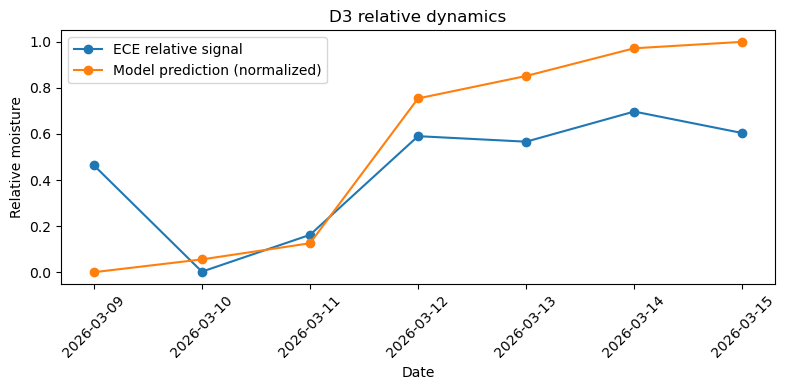

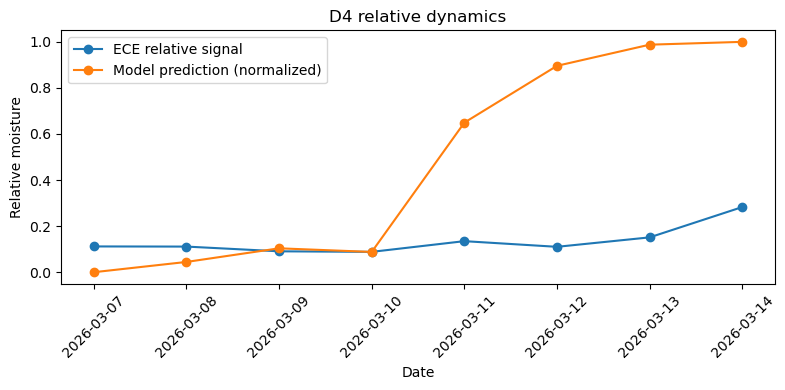

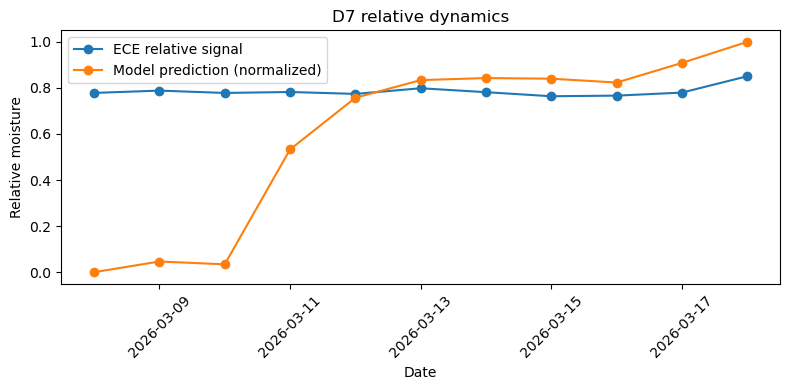

In [9]:
for dev, df in eval_outputs.items():
    plot_df = df.sort_values("date").copy()

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["date"], plot_df["ece_rel"], marker="o", label="ECE relative signal")
    plt.plot(plot_df["date"], plot_df["pred_rel"], marker="o", label="Model prediction (normalized)")
    plt.title(f"{dev.upper()} relative dynamics")
    plt.xlabel("Date")
    plt.ylabel("Relative moisture")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
def interpret_row(row):
    notes = []

    if row["n"] < 12:
        notes.append("very small sample")
    if row["ece_range"] < 10:
        notes.append("limited sensor dynamic range")
    if row["ece_range"] > 50:
        notes.append("high sensor variability / possible instability")

    return "; ".join(notes) if notes else "no major flag"

results_df["notes"] = results_df.apply(interpret_row, axis=1)
print(results_df)

  device   n    ece_min    ece_max  ece_range   ece_var  pred_var   pearson  spearman  trend_agreement  \
0     d3   7   0.234506  69.745718  69.511213  0.066877  0.206560  0.811899  0.821429         0.500000   
1     d4   8   8.832117  28.280082  19.447965  0.003995  0.206352  0.652658  0.547619         0.571429   
2     d7  11  76.381389  85.076533   8.695144  0.000556  0.149222  0.244541  0.227273         0.700000   

                                               notes  
0  very small sample; high sensor variability / p...  
1                                  very small sample  
2    very small sample; limited sensor dynamic range  


## Summary

At this point, it’s pretty clear that the ECE data just isn’t in a state where I can do any serious evaluation with it. I’m working with only 7 to 11 data points per device, and they’re not even in calibrated units, so there’s no way to assess actual soil moisture accuracy. Even the relative analysis is heavily constrained...some of the signals are noisy, others barely change, and the sample sizes are simply too small to support anything statistically meaningful

**Results:**

- `DEV3` shows relatively strong correlation (`Pearson ~= 0.81`, `Spearman ~= 0.82`), but this is based on only **7 points** and a highly unstable signal with a very large range `(~69)`. That makes it hard to treat this as reliable evidence...

- `DEV4` is more stable, but the correlation drops to a more moderate level (`Pearson ~= 0.65`), and the trend agreement `(~0.57)` is effectively indistinguishable from random at this sample size... 

- `DEV7` has very low variability (range `~8.7`), and as expected, the correlations are weak `(~=0.24)`, while the higher trend agreement `(~0.70)` is likely just an artifact of the flat signal rather than meaningful alignment...

> I'm aware the data quality here `(DEV7)` is not going to be up to par due to calibration issues...

In terms of whether the model loosely follows wet and dry behavior, there is some limited alignment, but that’s about as far as it goes. With only 7 to 11 observations per device, there simply isn’t enough data to draw any strong or defensible conclusions. This isn’t a modeling limitation, it’s just the reality of the data we have

At this stage, the ECE contribution can only be treated as very light supporting evidence rather than anything we can rely on for meaningful validation